---
## A Few Words About ESSEC Trading
---

In a world where access to information is the key to a successful investment strategy, institutional investors benefit from powerful and comprehensive tools such as **Bloomberg Terminal** or **FactSet**. These platforms centralize all necessary data and functionalities, but their exorbitant costs make them inaccessible to the majority of individual investors.

On the other hand, non-institutional investors face a paradox: a multitude of platforms, often specialized in fragmented functionalities (visualization, analysis, prediction, optimization, etc.), which make a coherent and centralized vision difficult. Add to this sometimes hidden costs for advanced features and questioning about data reliability, and it becomes clear that a real need exists: that of a centralized, accessible and reliable solution.

**How can we make advanced financial tools accessible to everyone, without compromising on quality or simplicity?**

Our project aims to answer precisely this question. By centralizing the essential tools for analysis, visualization, prediction and optimization on a single platform, we want to offer individual investors an intuitive and complete solution, based on reliable and up-to-date data. **ESSEC Trading** aspires to democratize access to advanced financial tools, while making investment more transparent, efficient and accessible to all.

---
## Creating the Database for ESSEC Trading
---

### Introduction 
This project is primarily based on data provided by the **yfinance** library: stock prices, past performance, market capitalization, company summaries, financial ratios, etc. However, to ensure optimal ease of use, we have added an enriched database with complementary information.

### Database Objective
We have integrated **company names**, their **associated ticker**, as well as the **reference index** in which they are listed. This structure allows the user to simply enter the name of a company they wish to analyze or add to their portfolio, without necessarily knowing its ticker. This significantly improves the platform's ergonomics and efficiency.

### Methodology
To build this database, we decided to **web scrape Wikipedia**, a reliable and easily accessible source, to extract essential data. We collected the compositions of the following indices:
- **S&P 500**
- **CAC 40**
- **DAX**
- **FTSE MIB**
- **FTSE 100**
- **IBEX 35**

### Limitation and Choice Excluding the Russell 2000
We initially included the complete composition of the **Russell 2000**, but decided to exclude it for practical reasons. This index, composed of American small caps, presents companies often newly listed, which limits the availability of historical data. The lack of this data prevented reliable calculation of the efficient frontier in our optimization module. For simplicity, we therefore preferred to remove this index from our database.

### Result
Below, you will find:
1. The code used to web scrape the necessary Wikipedia pages.
2. Simple descriptive statistics of our database, providing an overview of the collected information.
---

In [17]:
import sys
sys.path.append('Data')

import pandas as pd
import importlib
import data_fonctions as dgf
importlib.reload(dgf)

<module 'data_fonctions' from 'd:\\ESSEC M1\\ESSEC_Trading\\Data\\data_fonctions.py'>

---
#### S&P 500 - U.S.A.
---

In [18]:
# Load data for S&P 500 index
url_snp500 = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
df_snp500 = dgf.get_company_list(url_snp500, 'S&P 500')

# Initial data cleaning
df_snp500 = dgf.clean_snp500(df_snp500)

# Display
df_snp500.head()

,Ticker,Company,Ind
0,MMM,3M,S&P 500
1,AOS,A. O. Smith,S&P 500
2,ABT,Abbott Laboratories,S&P 500
3,ABBV,AbbVie,S&P 500
4,ACN,Accenture,S&P 500


---
#### CAC 40 - France
---

In [19]:
# Do the same for CAC 40 index
url_cac40 = "https://en.wikipedia.org/wiki/CAC_40"
df_cac40 = dgf.get_company_list(url_cac40, 'CAC 40')

df_cac40 = dgf.clean_cac40(df_cac40)

df_cac40.head()

,Ticker,Company,Ind
0,AC.PA,Accor,CAC 40
1,AI.PA,Air Liquide,CAC 40
2,AIR.PA,Airbus,CAC 40
3,MT.AS,ArcelorMittal,CAC 40
4,CS.PA,Axa,CAC 40


---
#### DAX - Germany
---

In [20]:
# Do the same for DAX index
url_dax = "https://en.wikipedia.org/wiki/DAX"
df_dax = dgf.get_company_list(url_dax, 'DAX')

df_dax = dgf.clean_dax(df_dax)

df_dax.head()

,Company,Ticker,Ind
0,Adidas,ADS.DE,DAX
1,Airbus,AIR.PA,DAX
2,Allianz,ALV.DE,DAX
3,BASF,BAS.DE,DAX
4,Bayer,BAYN.DE,DAX


---
#### FTSE MIB - Italy
---

In [21]:
# Do the same for FTSE MIB index
url_ftsemib = "https://en.wikipedia.org/wiki/FTSE_MIB"
df_ftsemib = dgf.get_company_list(url_ftsemib, 'FTSE MIB')

df_ftsemib = dgf.clean_ftsemib(df_ftsemib)

df_ftsemib.head()

,Company,Ticker,Ind
0,A2A,A2A.MI,FTSE MIB
1,Amplifon,AMP.MI,FTSE MIB
2,Azimut,AZM.MI,FTSE MIB
3,Banca Mediolanum,BMED.MI,FTSE MIB
4,Banca Monte dei Paschi di Siena,BMPS.MI,FTSE MIB


---
#### FTSE 100 - U.K.
---

In [22]:
# Do the same for FTSE 100 index
url_ftse100 = "https://en.wikipedia.org/wiki/FTSE_100_Index"
df_ftse100 = dgf.get_company_list(url_ftse100, 'FTSE 100')

df_ftse100 = dgf.clean_ftse100(df_ftse100)

df_ftse100.head()

,Ticker,Company,Ind
0,III.L,3i,FTSE 100
1,ADM.L,Admiral Group,FTSE 100
2,AAF.L,Airtel Africa,FTSE 100
3,ALW.L,Alliance Witan,FTSE 100
4,AAL.L,Anglo American plc,FTSE 100


---
#### IBEX 35 - Spain
---

In [23]:
# Do the same for IBEX 35 index
url_ibex35 = "https://en.wikipedia.org/wiki/IBEX_35"
df_ibex35 = dgf.get_company_list(url_ibex35, 'IBEX 35')

df_ibex35 = dgf.clean_ibex35(df_ibex35)

df_ibex35.head()

,Ticker,Company,Ind
0,ACS.MC,ACS,IBEX 35
1,ACX.MC,Acerinox,IBEX 35
2,AMS.MC,Amadeus IT Group,IBEX 35
3,ANA.MC,Acciona,IBEX 35
4,ANE.MC,Acciona Energía,IBEX 35


---
### Concatenation of Data
---

In [24]:
data_trading = pd.concat(
    [df_snp500, df_cac40, df_dax, df_ftsemib, df_ftse100, df_ibex35], 
    ignore_index=True)

---
### Descriptive Statistics
---

In [25]:
# Import required libraries
import matplotlib.pyplot as plt
import folium

In [26]:
# For simplicity, use df instead of data_pisquared
df = data_trading

In [27]:
# Descriptive statistics
total_rows = df.shape[0]
companies_per_index = df['Ind'].value_counts()
missing_values = df.isnull().sum()

print("Total number of rows:", total_rows)
print("Number of companies per stock index:", companies_per_index)
print("Missing values per column:", missing_values)

Total number of rows: 758
Number of companies per stock index: Ind
S&P 500     503
FTSE 100    100
CAC 40       40
DAX          40
FTSE MIB     40
IBEX 35      35
Name: count, dtype: int64
Missing values per column: Ticker     0
Company    0
Ind        0
dtype: int64


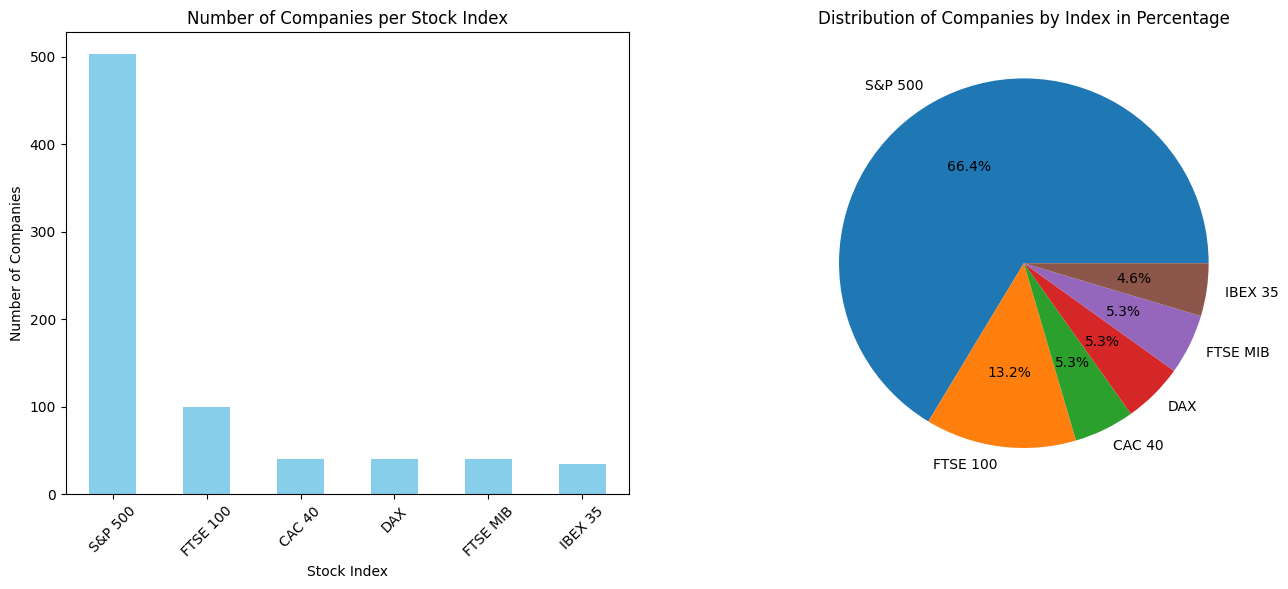

In [28]:
# Number of companies per stock index: barplot and pie chart

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Number of companies per stock index
companies_per_index.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Number of Companies per Stock Index')
axes[0].set_xlabel('Stock Index')
axes[0].set_ylabel('Number of Companies')
axes[0].tick_params(axis='x', rotation=45)

# Graph 2: Distribution in percentage
index_distribution = df['Ind'].value_counts(normalize=True) * 100 
axes[1].pie(index_distribution, labels=index_distribution.index, autopct='%1.1f%%')
axes[1].set_title('Distribution of Companies by Index in Percentage')

plt.show()

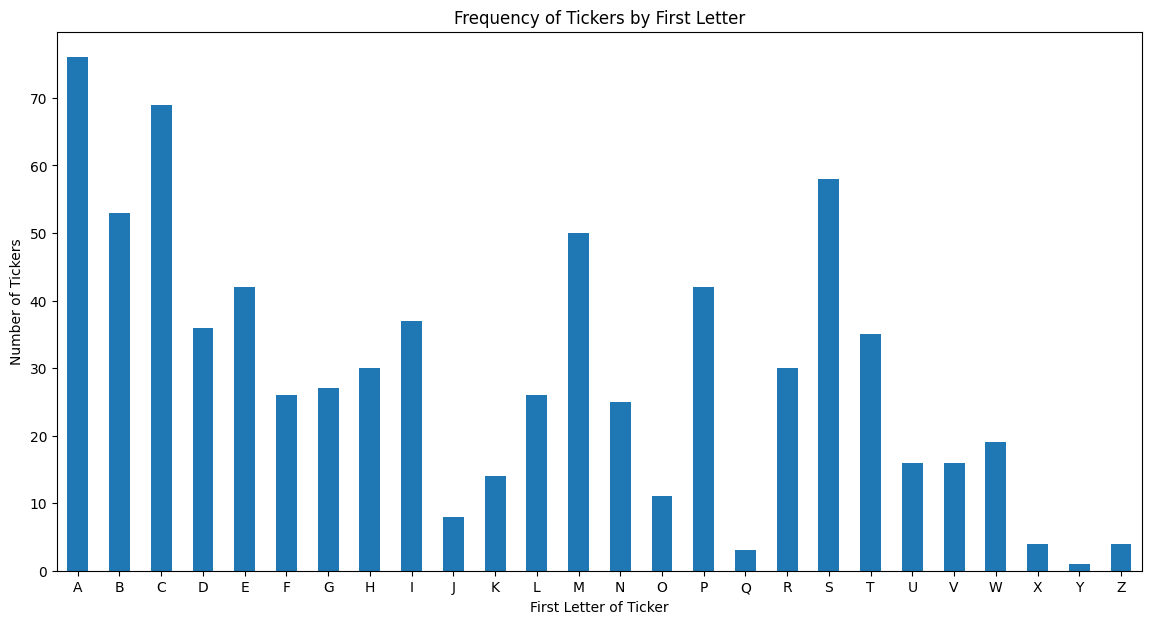

In [29]:
# Frequency of Tickers by First Letter

# Add a column with the first letter of each ticker
df['First_Letter'] = [ticker[0] for ticker in df['Ticker']]

# Count occurrences of each letter
letter_counts = df['First_Letter'].value_counts().sort_index()

# Visualization
plt.figure(figsize=(14, 7))
letter_counts.plot(kind='bar')
plt.title('Frequency of Tickers by First Letter')
plt.xlabel('First Letter of Ticker')
plt.ylabel('Number of Tickers')
plt.xticks(rotation=0)
plt.show()

In [30]:
#Geographical visualization of the companies
dgf.map_index(df)